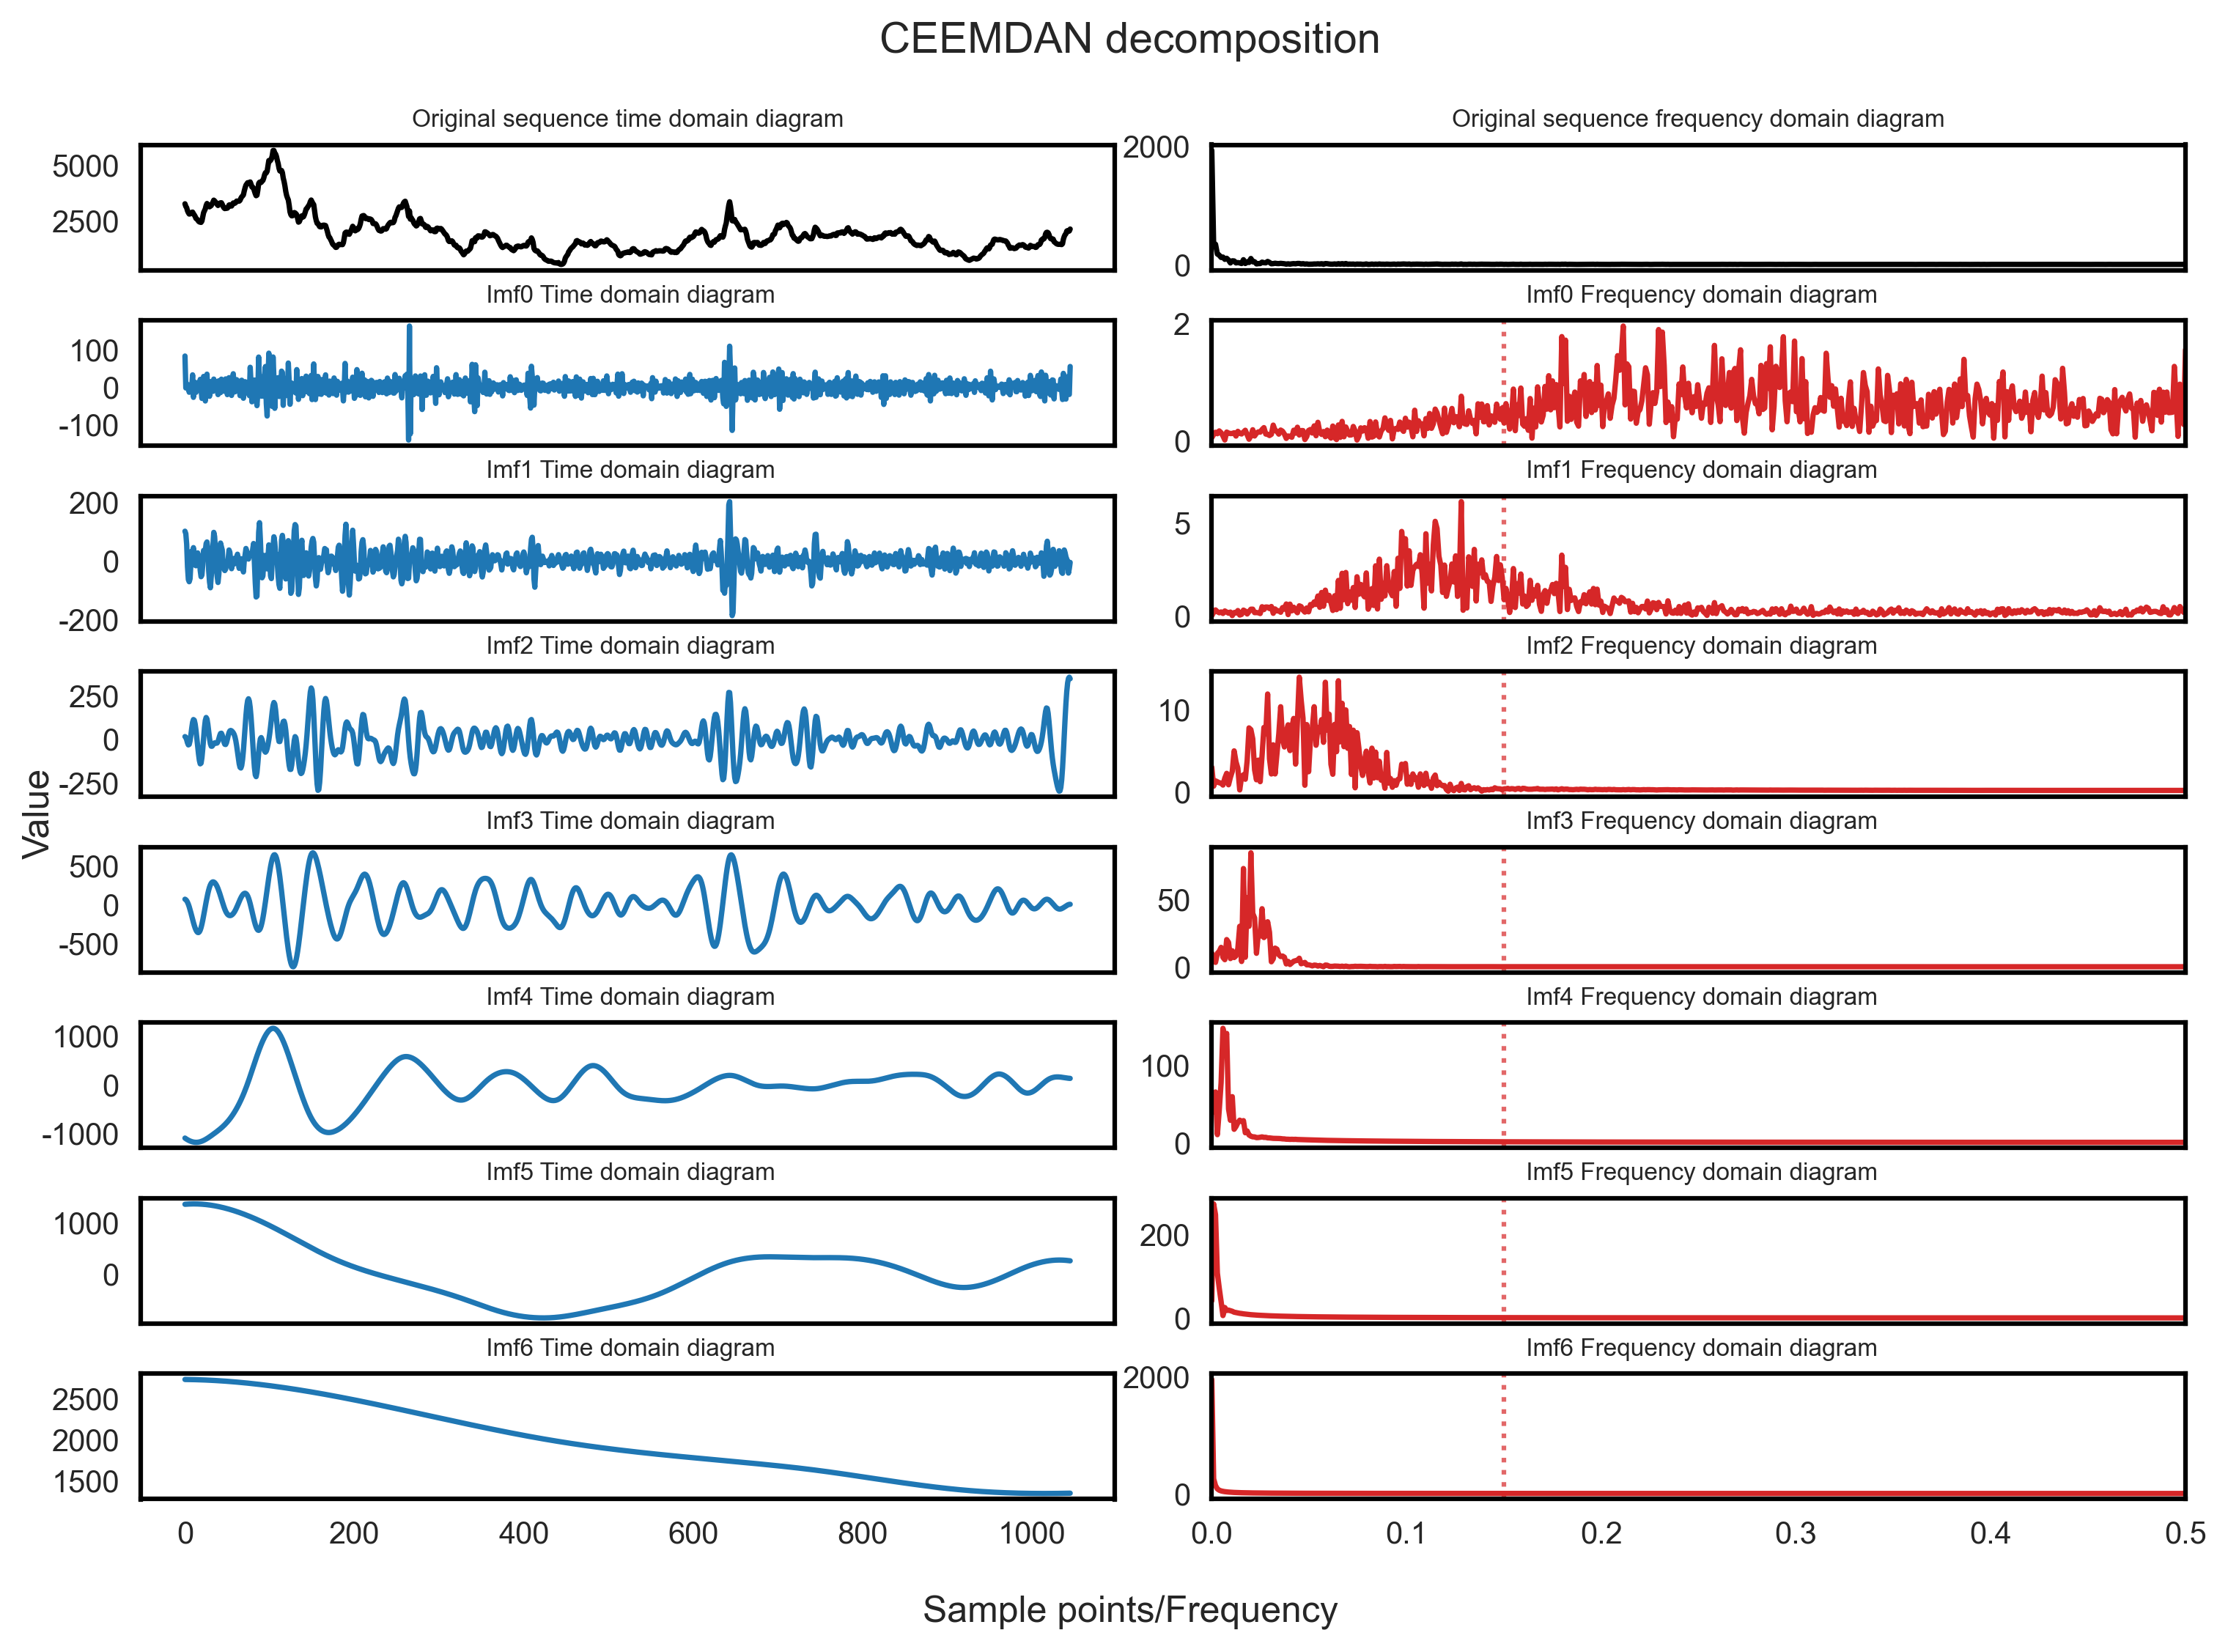

全数据长度: 1046
训练集长度: 732
测试集长度: 314
分解结果已保存至CEEMDAN_Datasets.xlsx


<Figure size 800x550 with 0 Axes>

In [5]:
import matplotlib.pyplot as plt
from PyEMD import CEEMDAN
import tensorflow as tf
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams['font.serif'] = ['Times New Roman']  
plt.rcParams['axes.unicode_minus'] = False  
plt.style.use('seaborn-v0_8')

plt.rcParams.update({
    'font.serif': 'Times New Roman', 
    'axes.unicode_minus': False,
    'font.size': 12,
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'axes.linewidth': 1.5,
    'axes.edgecolor': 'black',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'mathtext.fontset': 'stix' 
})

seed = 42
np.random.seed(seed)

df_raw_data = pd.read_excel(
    r'C:\Users\h\Desktop\小论文\BDI1000\BDI.xlsx', 
    usecols=[0, 1], 
    engine='openpyxl')
series_close = pd.Series(df_raw_data['y'].values)
def ceemdan_decompose(series=None, max_imf=-1, epsilon=0.1, ensemble_size=200):
    ceemdan = CEEMDAN(
        trials=ensemble_size,
        epsilon=epsilon,
        max_imf=max_imf,
        ext_EMD=None )
    imfs = ceemdan(series.values)
    df_ceemdan = pd.DataFrame(imfs.T)
    df_ceemdan.columns = [f'Imf{i}' for i in range(df_ceemdan.shape[1])]
    return df_ceemdan
df_ceemdan_full = ceemdan_decompose(series_close, max_imf=10)
show_imfs = df_ceemdan_full.shape[1]  
fig, axs = plt.subplots(nrows=show_imfs+1, 
                        ncols=2, 
                        figsize=(12, 1*(show_imfs+1)),
                        sharex='col',dpi=300)
plt.subplots_adjust(hspace=0.4, wspace=0.1)
axs[0,0].plot(series_close.values, color='black')  
axs[0,0].set_title("Original sequence time domain diagram", fontsize=8)
n = len(series_close)
Fs = 1.0
freq = np.fft.rfftfreq(n, d=1/Fs)
fft_vals = np.fft.rfft(series_close.values)
magnitude = np.abs(fft_vals)/n
axs[0,1].plot(freq, magnitude, color='black')
axs[0,1].set_title("Original sequence frequency domain diagram", fontsize=8)
axs[0,1].set_xlim(0, Fs/2)
for i in range(show_imfs):
    imf_col = f'Imf{i}'
        axs[i+1, 0].plot(df_ceemdan_full[imf_col].values, color='tab:blue')  
    axs[i+1, 0].set_title(f" {imf_col} Time domain diagram", fontsize=8)
    signal = df_ceemdan_full[imf_col].values
    n = len(signal)
    freq = np.fft.rfftfreq(n, d=1/Fs)
    fft_vals = np.fft.rfft(signal)
    magnitude = np.abs(fft_vals)/n
        axs[i+1, 1].plot(freq, magnitude, color='tab:red')
    axs[i+1, 1].set_title(f" {imf_col} Frequency domain diagram", fontsize=8)
    axs[i+1, 1].set_xlim(0, Fs/2)
    axs[i+1, 1].axvline(x=0.15, color='tab:red', linestyle=':', 
                        linewidth=1.5, alpha=0.7)
fig.text(0.5, 0.04, 'Sample points/Frequency', ha='center', fontsize=12)
fig.text(0.08, 0.5, 'Value', va='center', rotation='vertical', fontsize=12)
plt.suptitle('CEEMDAN decomposition', y=0.95, fontsize=14)
plt.savefig('C:/Users/h/Desktop/小论文/BDI1000/CEEMDAN_Decomposition.eps', format='eps', dpi=300)
plt.show()
split_idx = int(len(series_close) * 0.7)
train_imfs = df_ceemdan_full.iloc[:split_idx, :]
test_imfs = df_ceemdan_full.iloc[split_idx:, :]
train_series = series_close.iloc[:split_idx]
test_series = series_close.iloc[split_idx:]
with pd.ExcelWriter("C:/Users/h/Desktop/小论文/BDI1000/CEEMDAN_Datasets.xlsx") as writer:
    train_imfs.to_excel(writer, sheet_name='Train_IMFs', index=False)
    test_imfs.to_excel(writer, sheet_name='Test_IMFs', index=False)
    train_series.to_frame(name='Original').to_excel(writer, sheet_name='Train_Original', index=False)
    test_series.to_frame(name='Original').to_excel(writer, sheet_name='Test_Original', index=False)

print(f"全数据长度: {len(series_close)}")
print(f"训练集长度: {len(train_series)}")
print(f"测试集长度: {len(test_series)}")
print("分解结果已保存至CEEMDAN_Datasets.xlsx")

Maximum reconstruction error: 1.82e-12
IMF 1: 1.9767
IMF 2: 1.6160
IMF 3: 0.5993
IMF 4: 0.5045
IMF 5: 0.1392
IMF 6: 0.0262
IMF 7: 0.0025


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


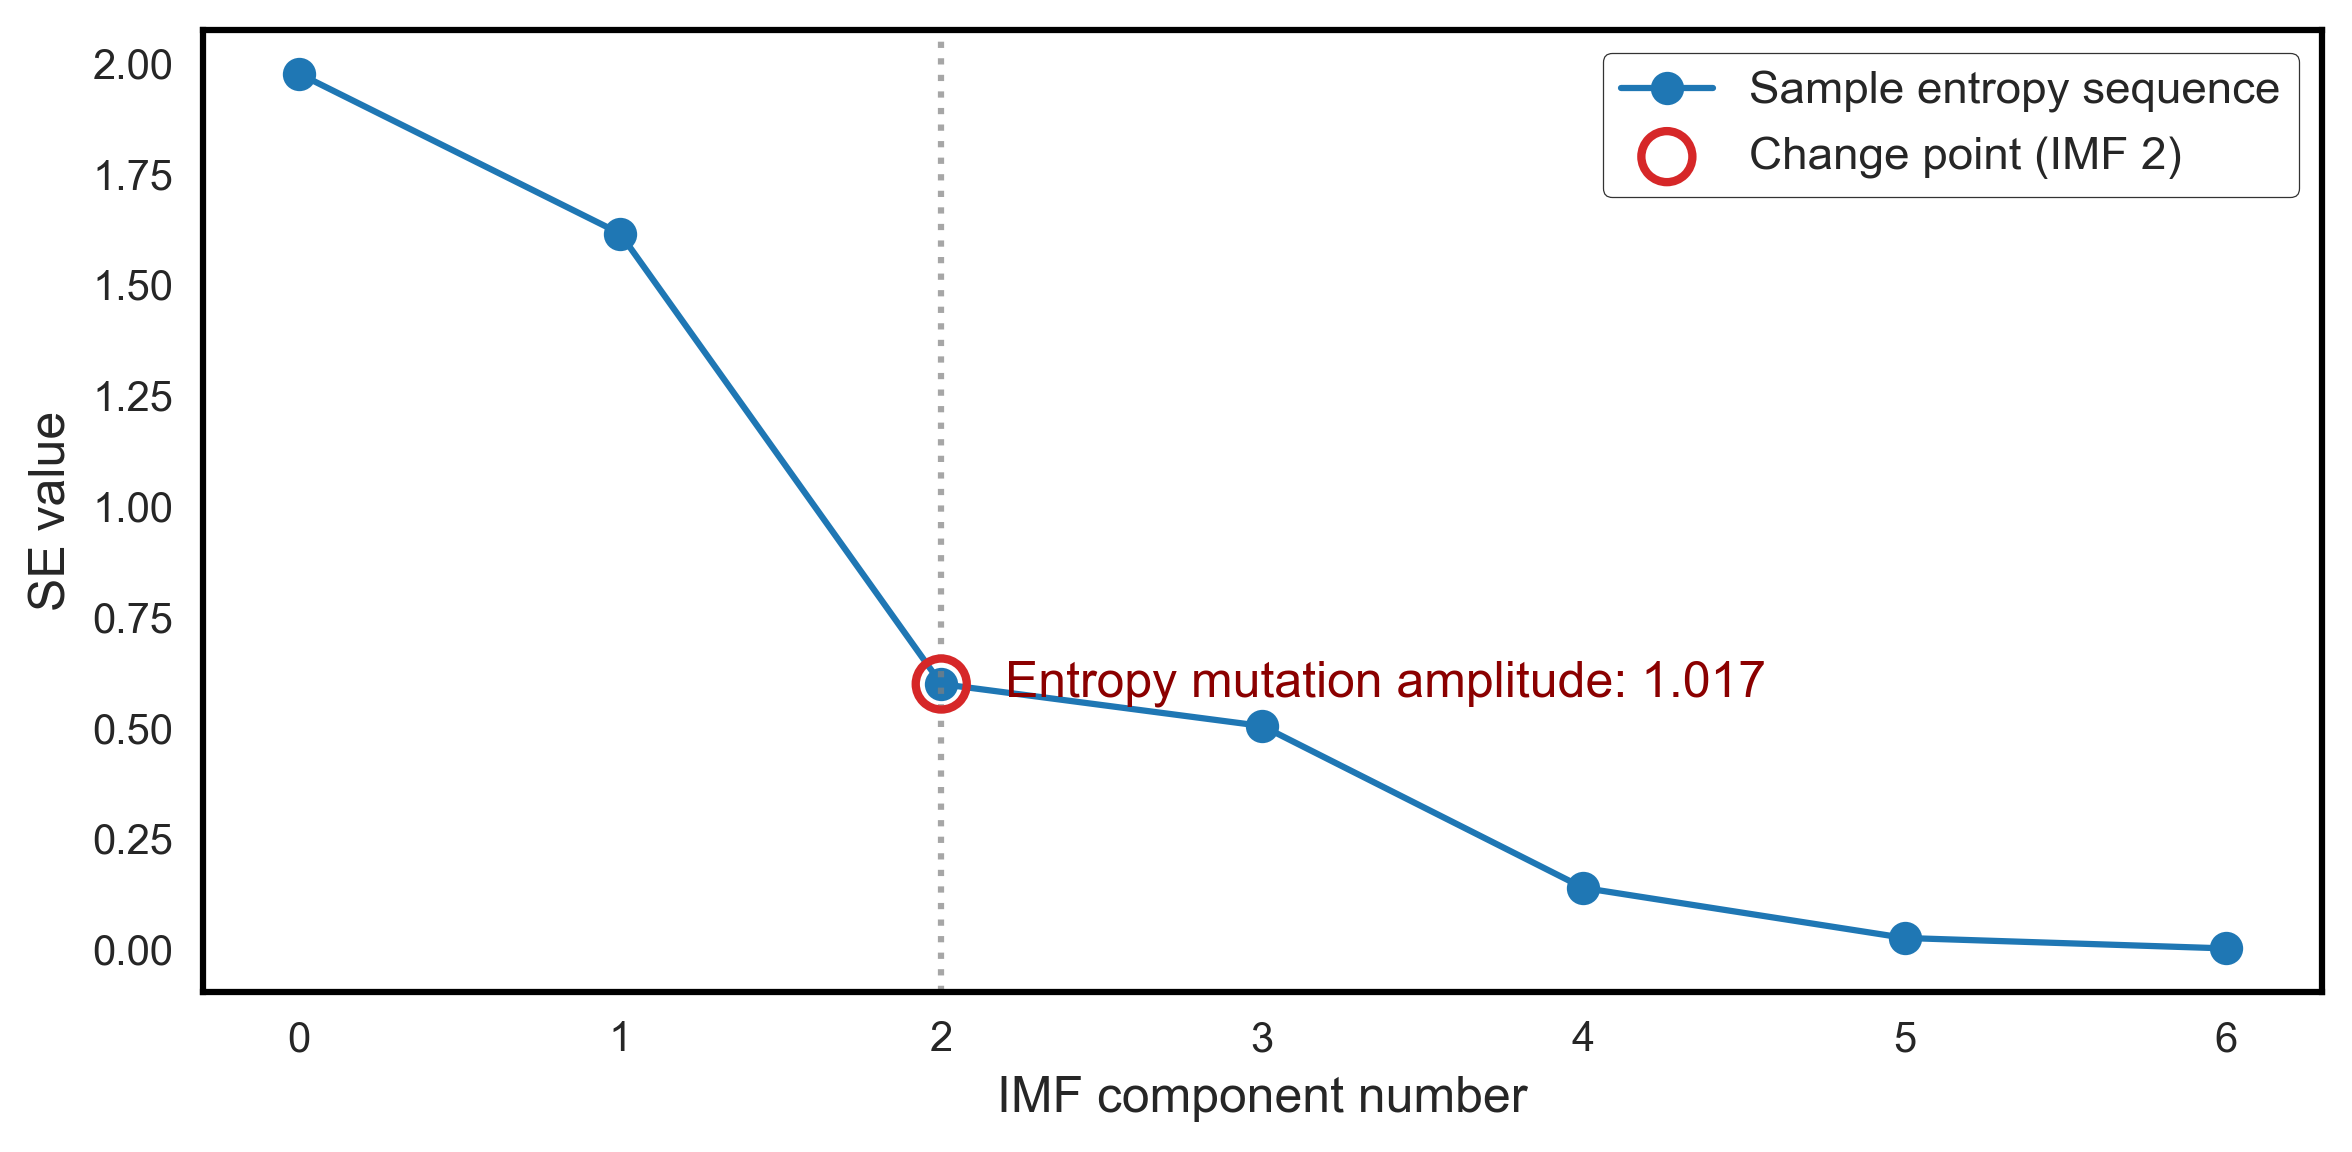

Change point location: IMF 3
High-frequency component IMF number: [1, 2]
Low-frequency component IMF number: [3, 4, 5, 6, 7]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


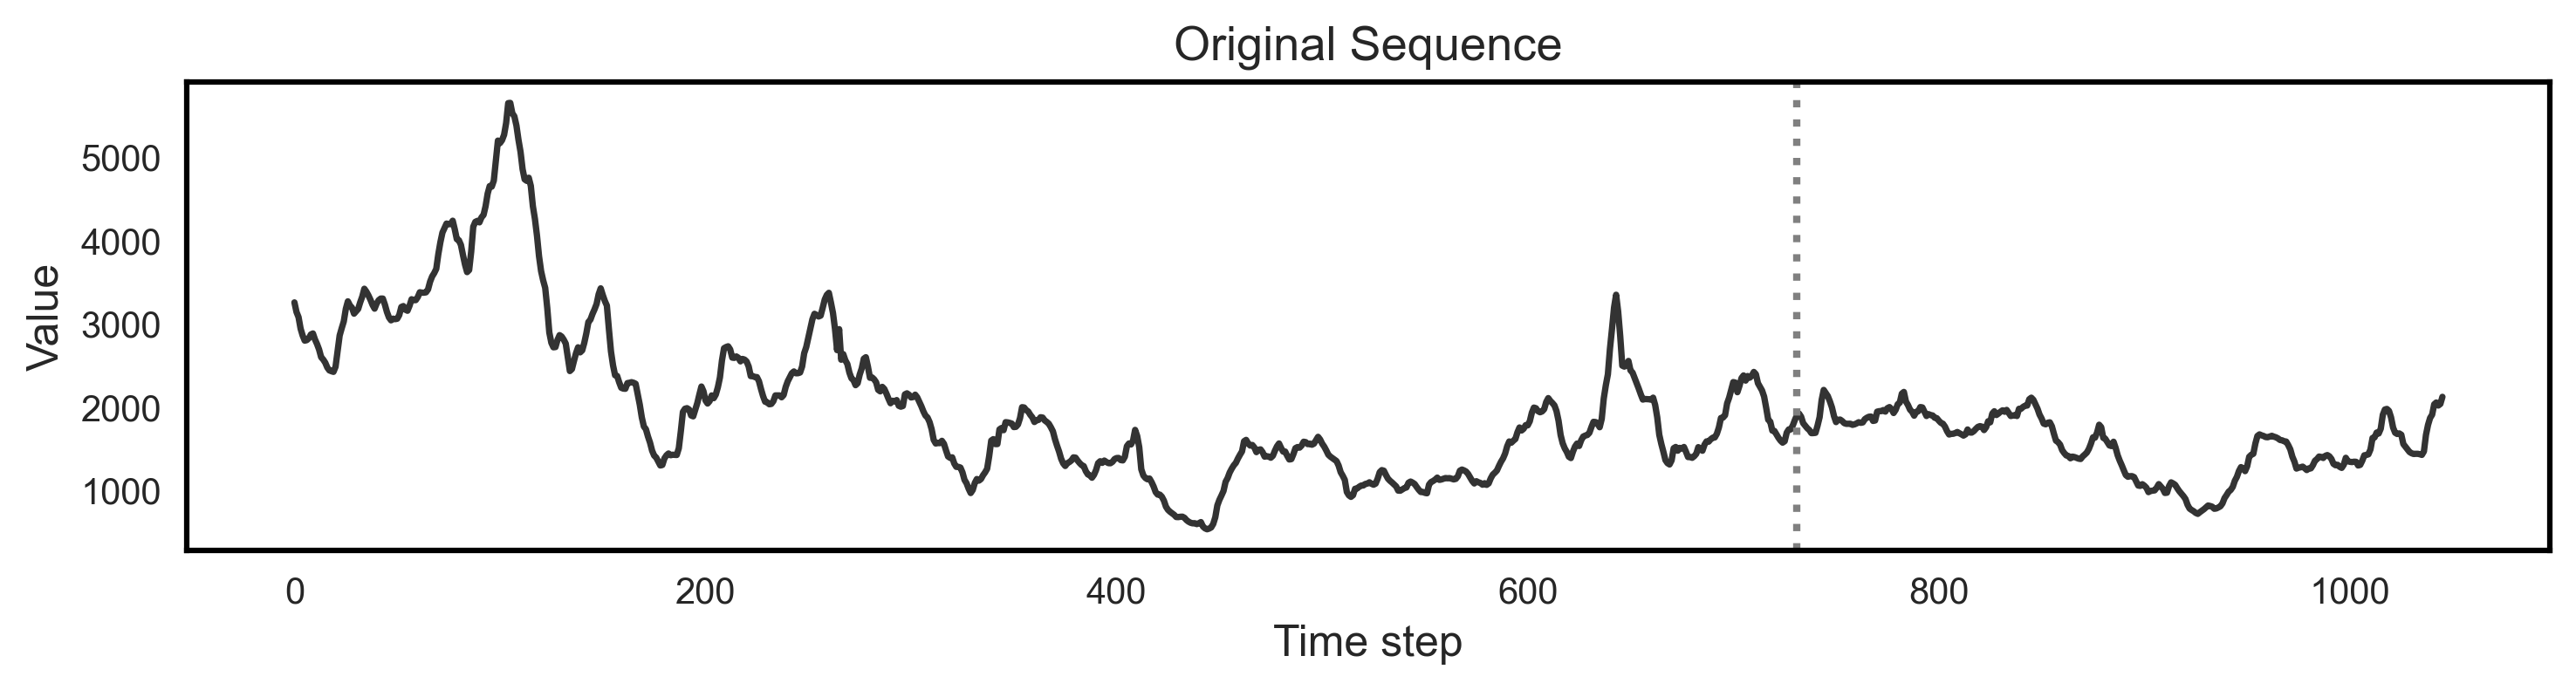

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


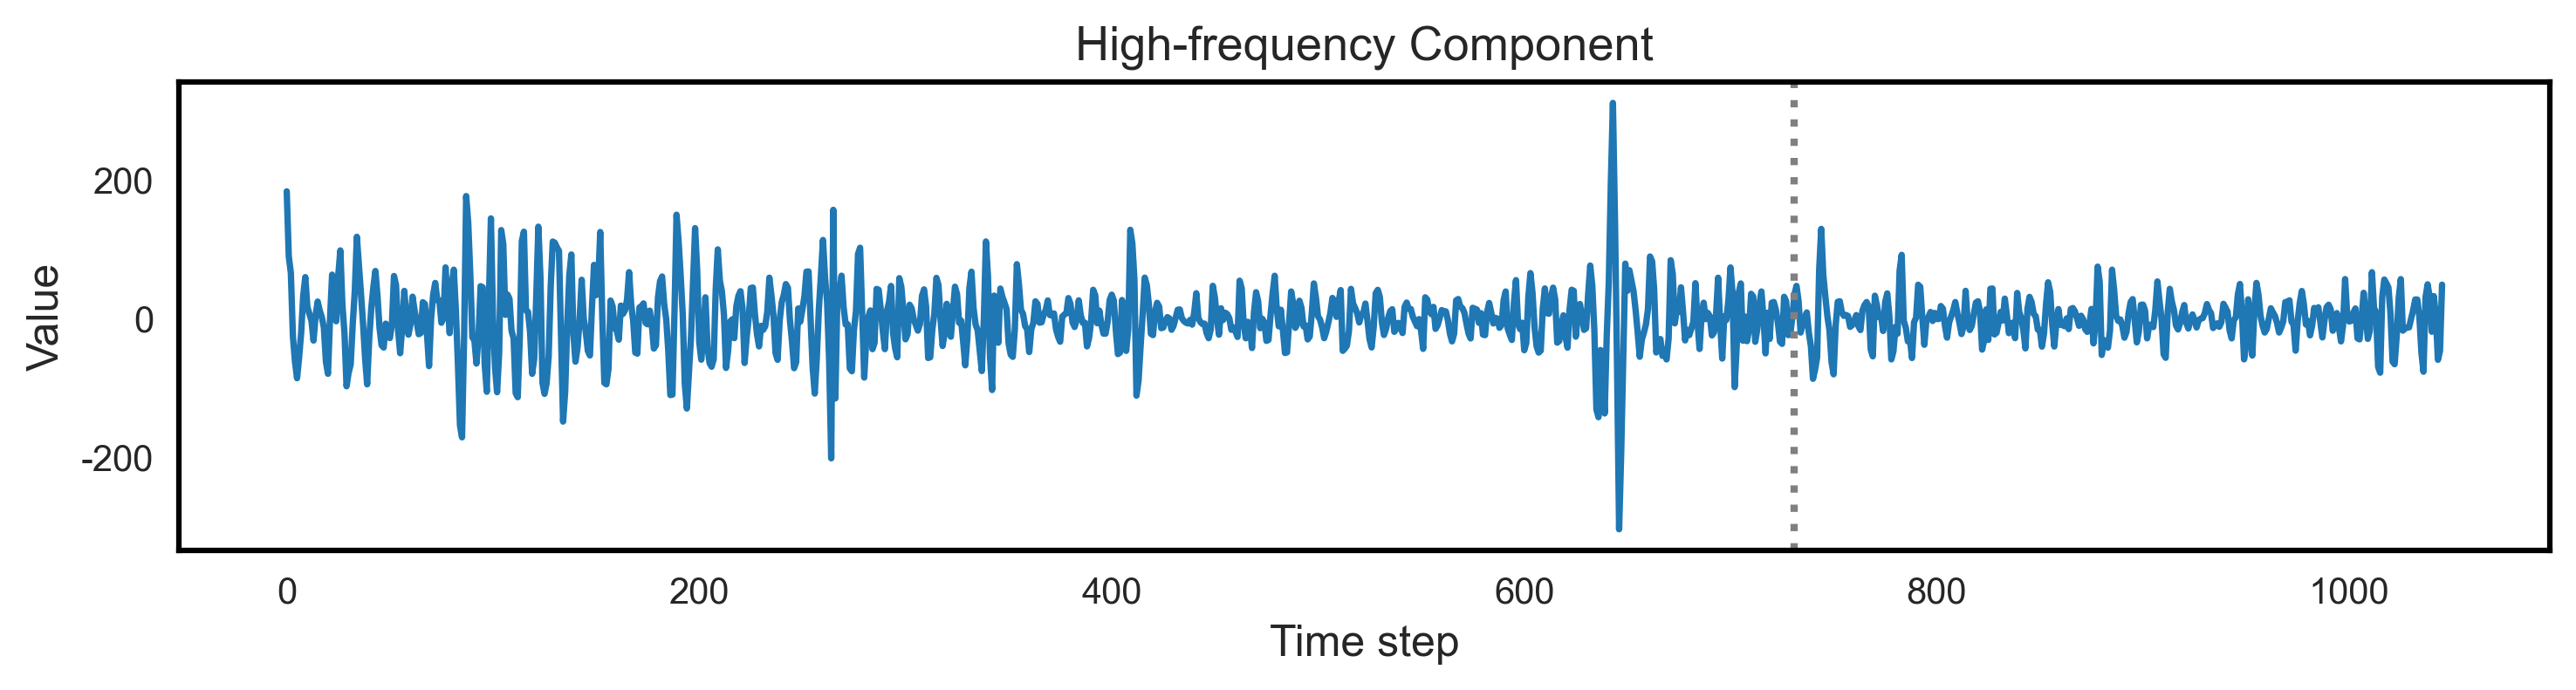

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


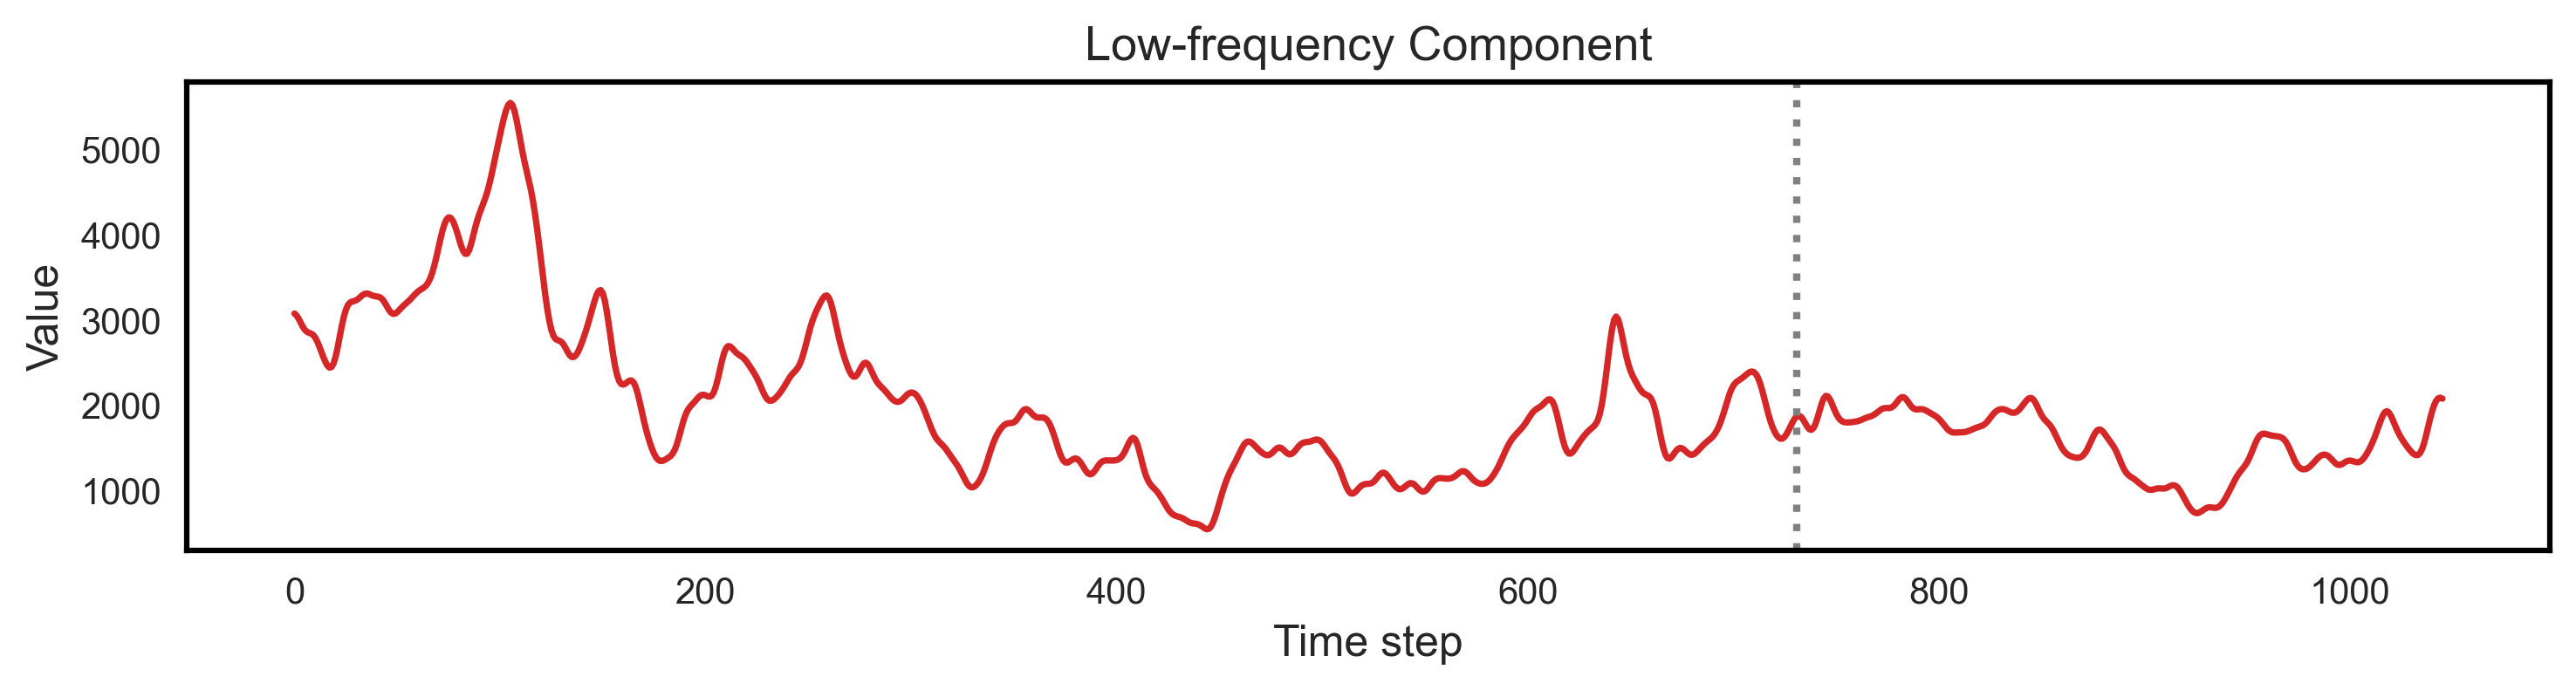

In [2]:
raw_data = pd.read_excel(r'C:\Users\h\Desktop\小论文\BDI1000\BDI.xlsx', sheet_name='Sheet1')
original_spread = raw_data.iloc[:, 1].values.ravel()  
train_imfs = pd.read_excel(r'C:\Users\h\Desktop\小论文\BDI1000\CEEMDAN_Datasets.xlsx', sheet_name='Train_IMFs')
test_imfs = pd.read_excel(r'C:\Users\h\Desktop\小论文\BDI1000\CEEMDAN_Datasets.xlsx', sheet_name='Test_IMFs')
full_imfs = pd.concat([train_imfs, test_imfs], axis=0).values.T
reconstructed_spread = np.sum(full_imfs, axis=0)
validation_error = np.max(np.abs(reconstructed_spread - original_spread))
print(f"Maximum reconstruction error: {validation_error:.2e}")
assert np.allclose(reconstructed_spread, original_spread, atol=1e-5), "≠"


def sample_entropy(time_series, m=2, r=0.15):
    n = len(time_series)
    if n <= m + 1:
        return 0.0    
    r_val = r * np.std(time_series)
    if r_val == 0:
        return 0.0    
    def _get_vectors(dim):
        return [time_series[i:i+dim] for i in range(n - dim + 1)]    
    vectors_m = _get_vectors(m)
    vectors_m1 = _get_vectors(m + 1)    
    B = sum(1 for i in range(len(vectors_m)) for j in range(i+1, len(vectors_m)) 
            if max(abs(np.array(vectors_m[i]) - np.array(vectors_m[j]))) <= r_val)
    A = sum(1 for i in range(len(vectors_m1)) for j in range(i+1, len(vectors_m1)) 
          if max(abs(np.array(vectors_m1[i]) - np.array(vectors_m1[j]))) <= r_val)    
    N = len(vectors_m)
    B = B / (N * (N - 1) / 2) if N > 1 else 0
    A = A / ((N-1) * (N-2) / 2) if N > 2 else 0    
    return -np.log(A / B) if A != 0 and B != 0 else 0
sample_entropies = [sample_entropy(imf) for imf in full_imfs]
for i, se in enumerate(sample_entropies, 1):
    print(f"IMF {i}: {se:.4f}")
median_se = np.median(sample_entropies)
sample_entropies_diff = np.abs(np.diff(sample_entropies))
max_change_idx = np.argmax(sample_entropies_diff) + 1  
max_change_value = sample_entropies[max_change_idx]
plt.figure(figsize=(8, 4),dpi=300)
plt.plot(range(0, len(sample_entropies)), sample_entropies, 
         marker='o', markersize=8, color='tab:blue', 
         linewidth=1.5, label='Sample entropy sequence')
plt.scatter(max_change_idx, max_change_value, s=150, 
            facecolors='none', edgecolors='tab:red', 
            linewidths=2, zorder=5, 
            label=f'Change point (IMF {max_change_idx})')
plt.axvline(x=max_change_idx, color='gray', linestyle=':', 
            linewidth=1.5, alpha=0.7)
plt.text(max_change_idx+0.2, max_change_value, 
         f'Entropy mutation amplitude: {sample_entropies_diff[max_change_idx-1]:.3f}',
         ha='left', va='center', color='darkred')
plt.xlabel('IMF component number', fontsize=12)
plt.ylabel('SE value', fontsize=12)
plt.xticks(range(0, len(sample_entropies)))
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='black', fontsize=11)
plt.tight_layout()
plt.savefig('C:/Users/h/Desktop/小论文/BDI1000/IMF sample entropy change point detection.eps', format='eps', dpi=300)
plt.show()
high_freq_indices = list(range(max_change_idx))  
low_freq_indices = list(range(max_change_idx, len(sample_entropies)))
print(f"Change point location: IMF {max_change_idx + 1}")
print(f"High-frequency component IMF number: {[i+1 for i in high_freq_indices]}")
print(f"Low-frequency component IMF number: {[i+1 for i in low_freq_indices]}")
high_freq = full_imfs[high_freq_indices, :].sum(axis=0)
low_freq = full_imfs[low_freq_indices, :].sum(axis=0)
result_df = pd.DataFrame({
    'Original sequence': original_spread,
    'High-frequency component': high_freq,
    'Low-frequency component': low_freq
})
result_df.to_excel(r'C:\Users\h\Desktop\小论文\BDI1000\CEEMDAN.xlsx', index=False)


split_point = len(train_imfs)


plt.figure(figsize=(10, 2.8), dpi=300)
plt.plot(original_spread, color='black', alpha=0.8)
plt.title('Original Sequence', fontsize=13)
plt.xlabel('Time step', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.axvline(x=split_point-1, color='gray', linestyle=':', linewidth=2)
plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig('C:/Users/h/Desktop/小论文/BDI1000/Original sequence.eps', format='eps', dpi=300)
plt.show()

plt.figure(figsize=(10, 2.8), dpi=300)
plt.plot(high_freq, color='tab:blue')
plt.title('High-frequency Component', fontsize=13)
plt.xlabel('Time step', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.axvline(x=split_point-1, color='gray', linestyle=':', linewidth=2)
plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig('C:/Users/h/Desktop/小论文/BDI1000/High-frequency Component.eps', format='eps', dpi=300)
plt.show()

plt.figure(figsize=(10,2.8), dpi=300)
plt.plot(low_freq, color='tab:red')
plt.title('Low-frequency Component', fontsize=13)
plt.xlabel('Time step', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.axvline(x=split_point-1, color='gray', linestyle=':', linewidth=2)
plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig('C:/Users/h/Desktop/小论文/BDI1000/Low-frequency Component.eps', format='eps', dpi=300)
plt.show()